In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

# Настройки matplotlib
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

Форма X_design: (100, 2)
Форма y: (100,)


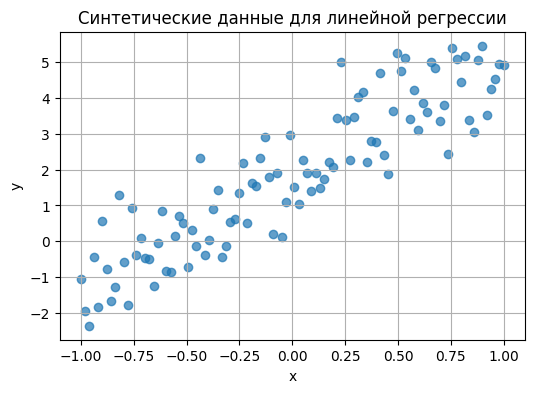

In [46]:
n = 100
X = np.linspace(-1, 1, n).reshape(-1, 1)
true_w = np.array([3.0])
true_b = 2.0
noise = np.random.normal(0, 1, size=(n, ))
y = (X[:, 0] * true_w[0] + true_b + noise)

# Сделаем матрицу X с единичным столбцом для b
X_design = np.hstack([X, np.ones((n, 1))])  # [x, 1] — последний столбец для смещения

print("Форма X_design:", X_design.shape)
print("Форма y:", y.shape)

plt.scatter(X, y, alpha=0.7)
plt.title("Синтетические данные для линейной регрессии")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 1. Линейная регрессия в матричном виде

Задача: по признакам `x` предсказать числовой ответ `y`.

Модель (в матричном виде):

$
X \in \mathbb{R}^{n \times d},\quad w \in \mathbb{R}^{d},\quad y \in \mathbb{R}^{n}
$

$
\hat{y} = X w
$

Ошибка (MSE — среднеквадратичное отклонение):

$
L(w) = \frac{1}{n}\|X w - y\|^2
$

Минимум достигается при решении нормального уравнения:

$
X^T X w = X^T y,\qquad
w^\* = (X^T X)^{-1} X^T y
$

Альтернатива: искать минимум методом градиентного спуска.

Аналитическое решение: w = 3.200, b = 1.878
Истинные параметры:   w = 3.000, b = 2.000


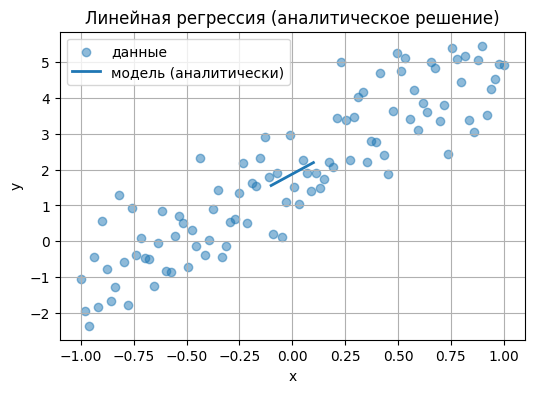

In [47]:
# w_full = [w, b]
XtX = X_design.T @ X_design
Xty = X_design.T @ y

w_full_closed_form = np.linalg.inv(XtX) @ Xty
w_hat, b_hat = w_full_closed_form[0], w_full_closed_form[1]

print(f"Аналитическое решение: w = {w_hat:.3f}, b = {b_hat:.3f}")
print(f"Истинные параметры:   w = {true_w[0]:.3f}, b = {true_b:.3f}")

# Визуализация
x_plot = np.linspace(-0.1, 0.1, 100).reshape(-1, 1)
X_plot_design = np.hstack([x_plot, np.ones((100, 1))])
y_pred = X_plot_design @ w_full_closed_form

plt.scatter(X, y, alpha=0.5, label="данные")
plt.plot(x_plot, y_pred, label="модель (аналитически)", linewidth=2)
plt.legend()
plt.title("Линейная регрессия (аналитическое решение)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

После градиентного спуска:
w = 3.023, b = 1.896


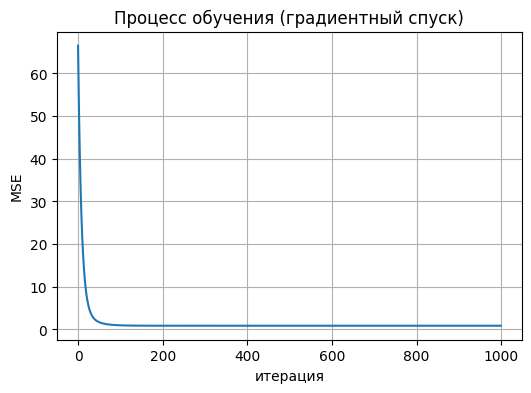

In [4]:
# Инициализация параметров случайно
w_gd = np.random.randn(2)  # [w, b]
lr = 0.01
num_iters = 1000

loss_history = []

for it in range(num_iters):
    # Прямой проход
    y_pred = X_design @ w_gd  # (n,) = (n, 2) @ (2,)
    
    # Потеря MSE
    error = y_pred - y
    loss = (error @ error) / n   # скаляр
    loss_history.append(loss)
    
    # Градиент по w_gd
    # dL/dw = (2/n) * X^T (X w - y)
    grad = (2.0 / n) * (X_design.T @ error)
    
    # Шаг градиентного спуска
    w_gd -= lr * grad

print("После градиентного спуска:")
print(f"w = {w_gd[0]:.3f}, b = {w_gd[1]:.3f}")

plt.plot(loss_history)
plt.xlabel("итерация")
plt.ylabel("MSE")
plt.title("Процесс обучения (градиентный спуск)")
plt.show()

## 2. Логистическая регрессия (бинарная классификация)

Задача: по признакам `x` предсказать класс `y ∈ {0, 1}`.

Модель:
$
z = w^T x + b,\quad
\sigma(z) = \frac{1}{1 + e^{-z}}
$
$
\hat{y} = \sigma(w^T x + b)
$

Интерпретация: $\hat{y}$ — вероятность класса 1.

Функция потерь — логистическая (бинарная кросс-энтропия):

$
L(w, b) =
-\frac{1}{n}\sum_{i=1}^n
\left( y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i)\right)
$

Обучаем параметры $(w, b)$ градиентным спуском.

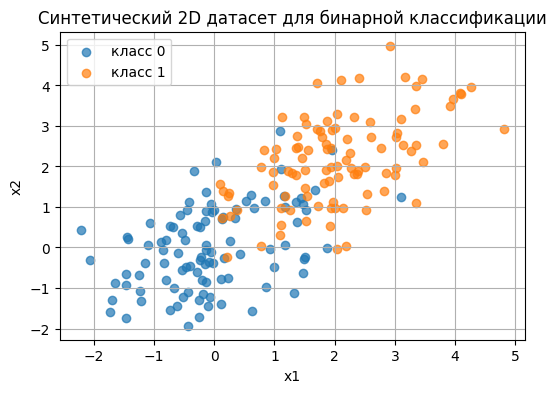

In [48]:
# Сгенерируем 2D точки двух классов
n_per_class = 100

mean0 = np.array([0, 0])
mean1 = np.array([2, 2])
cov = np.array([[1.0, 0.5], [0.5, 1.0]])

X0 = np.random.multivariate_normal(mean0, cov, size=n_per_class)
X1 = np.random.multivariate_normal(mean1, cov, size=n_per_class)

X_bin = np.vstack([X0, X1])  # (200, 2)
y_bin = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])  # (200,)

plt.scatter(X0[:, 0], X0[:, 1], label="класс 0", alpha=0.7)
plt.scatter(X1[:, 0], X1[:, 1], label="класс 1", alpha=0.7)
plt.legend()
plt.title("Синтетический 2D датасет для бинарной классификации")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Финальная потеря: 0.31446688996573663


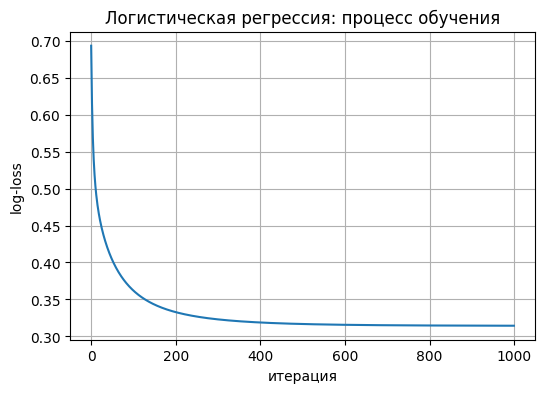

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_loss_and_grad(X, y, w):
    """
    X: (n, d+1) — с единичным столбцом для b
    y: (n,)
    w: (d+1,)
    """
    n = X.shape[0]
    z = X @ w           # (n,)
    y_hat = sigmoid(z)  # (n,)
    
    # Чуть-чуть численной стабильности
    eps = 1e-15
    y_hat_clipped = np.clip(y_hat, eps, 1 - eps)
    
    # Логистическая потеря
    loss = -np.mean(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
    
    # Градиент: (1/n) * X^T (y_hat - y)
    grad = (1.0 / n) * (X.T @ (y_hat - y))
    return loss, grad

# Добавим столбец 1 для b
X_bin_design = np.hstack([X_bin, np.ones((X_bin.shape[0], 1))])  # (n, 3)
w_log = np.zeros(X_bin_design.shape[1])

lr = 0.1
num_iters = 1000
loss_history_log = []

for it in range(num_iters):
    loss, grad = logistic_loss_and_grad(X_bin_design, y_bin, w_log)
    loss_history_log.append(loss)
    w_log -= lr * grad

print("Финальная потеря:", loss_history_log[-1])

plt.plot(loss_history_log)
plt.xlabel("итерация")
plt.ylabel("log-loss")
plt.title("Логистическая регрессия: процесс обучения")
plt.show()

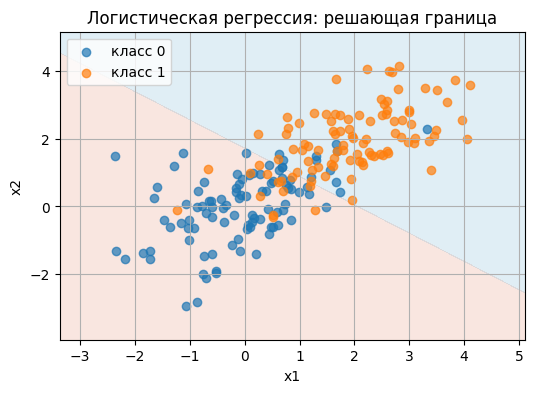

In [11]:
# Сетка для визуализации
xx, yy = np.meshgrid(
    np.linspace(X_bin[:, 0].min() - 1, X_bin[:, 0].max() + 1, 100),
    np.linspace(X_bin[:, 1].min() - 1, X_bin[:, 1].max() + 1, 100)
)

grid = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.size)]  # (N, 3)
probs = sigmoid(grid @ w_log).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2, cmap="RdBu")
plt.scatter(X0[:, 0], X0[:, 1], label="класс 0", alpha=0.7)
plt.scatter(X1[:, 0], X1[:, 1], label="класс 1", alpha=0.7)

plt.title("Логистическая регрессия: решающая граница")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

Форма X_img: (1797, 64)
Уникальные метки: [0 1 2 3 4 5 6 7 8 9]
Train: (1437, 64) Test: (360, 64)


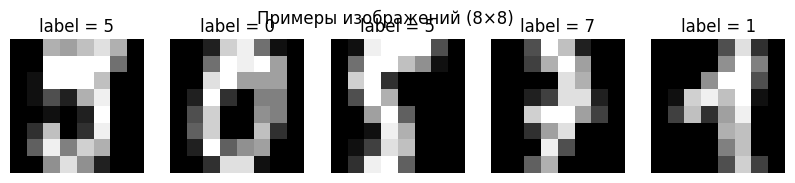

In [12]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X_img = digits.data        # (n_samples, 64) — 8×8 изображения, расплющенные
y_img = digits.target      # (n_samples,)

print("Форма X_img:", X_img.shape)
print("Уникальные метки:", np.unique(y_img))

# Нормализация пикселей к [0, 1]
X_img = X_img / 16.0

# Разделим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_img, test_size=0.2, random_state=42, stratify=y_img
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Покажем пару примеров
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"label = {y_train[i]}")
    ax.axis("off")
plt.suptitle("Примеры изображений (8×8)")
plt.show()

In [13]:
num_classes = 10
num_features = X_train.shape[1]

# Инициализация параметров
W = 0.01 * np.random.randn(num_features, num_classes)
b = np.zeros(num_classes)

def softmax(z):
    # z: (n, K)
    z_shifted = z - z.max(axis=1, keepdims=True)  # для численной стабильности
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def cross_entropy_loss(X, y, W, b):
    """
    X: (n, d)
    y: (n,) целые метки 0..K-1
    W: (d, K)
    b: (K,)
    """
    n = X.shape[0]
    logits = X @ W + b  # (n, K)
    probs = softmax(logits)  # (n, K)
    # Выбираем вероятность правильного класса
    correct_logprobs = -np.log(probs[np.arange(n), y] + 1e-15)
    loss = np.mean(correct_logprobs)
    return loss, probs

def compute_gradients(X, y, W, b):
    """
    Возвращает градиенты dW, db.
    """
    n = X.shape[0]
    logits = X @ W + b
    probs = softmax(logits)  # (n, K)
    
    # dL/dlogits = probs - one_hot(y)
    probs[np.arange(n), y] -= 1  # (n, K)
    dW = (X.T @ probs) / n       # (d, K)
    db = probs.mean(axis=0)      # (K,)
    return dW, db

def accuracy(X, y, W, b):
    logits = X @ W + b
    preds = np.argmax(logits, axis=1)
    return np.mean(preds == y)

Epoch  10: loss = 0.371, test accuracy = 0.933
Epoch  20: loss = 0.252, test accuracy = 0.936
Epoch  30: loss = 0.203, test accuracy = 0.947
Epoch  40: loss = 0.176, test accuracy = 0.958
Epoch  50: loss = 0.158, test accuracy = 0.961
Epoch  60: loss = 0.143, test accuracy = 0.961
Epoch  70: loss = 0.133, test accuracy = 0.958
Epoch  80: loss = 0.125, test accuracy = 0.969
Epoch  90: loss = 0.117, test accuracy = 0.961
Epoch 100: loss = 0.112, test accuracy = 0.964


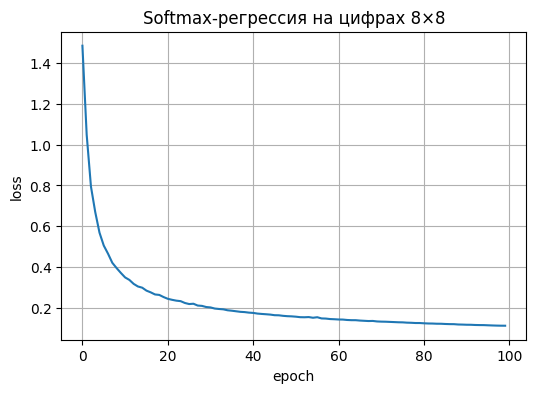

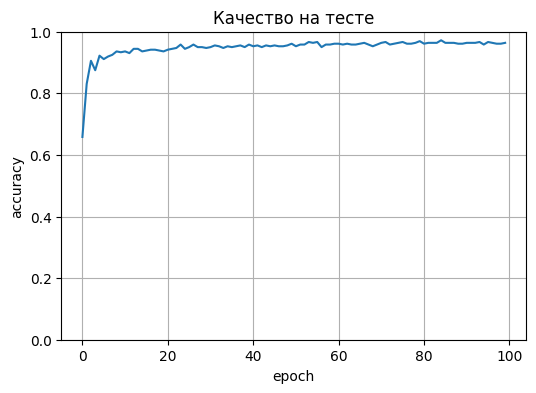

In [14]:
lr = 0.5
num_epochs = 100
batch_size = 128

train_losses = []
test_accs = []

for epoch in range(num_epochs):
    # мини-батчи
    idx = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]
    
    for start in range(0, X_train.shape[0], batch_size):
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]
        
        dW, db = compute_gradients(X_batch, y_batch, W, b)
        W -= lr * dW
        b -= lr * db
    
    train_loss, _ = cross_entropy_loss(X_train, y_train, W, b)
    train_losses.append(train_loss)
    test_acc = accuracy(X_test, y_test, W, b)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}: loss = {train_loss:.3f}, test accuracy = {test_acc:.3f}")

plt.plot(train_losses, label="train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Softmax-регрессия на цифрах 8×8")
plt.show()

plt.plot(test_accs, label="test accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Качество на тесте")
plt.ylim(0, 1)
plt.show()

In [49]:
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)

In [16]:
# Загрузка датасета кошек и собак

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

zip_path = data_dir / "cats_dogs_light.zip"
dataset_url = "https://zenodo.org/records/5226945/files/cats_dogs_light.zip?download=1"

if not zip_path.exists():
    print("Скачиваю датасет Cats & Dogs (~30 МБ)...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Готово.")
else:
    print("Архив уже скачан.")

extract_dir = data_dir / "cats_dogs_light"

if not extract_dir.exists():
    print("Распаковываю архив...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)
    print("Готово.")
else:
    print("Архив уже распакован.")


Скачиваю датасет Cats & Dogs (~30 МБ)...
Готово.
Распаковываю архив...
Готово.


In [17]:
# Проверим структуру директорий

for root, dirs, files in os.walk(extract_dir):
    print(root, " | подкаталоги:", dirs[:5], " | файлов:", len(files))
    break  # смотрим только верхний уровень


data/cats_dogs_light  | подкаталоги: ['test', 'train']  | файлов: 0


In [20]:
# Функция загрузки изображений
# ожидаем структуру:
# data/cats_dogs_light/cats_dogs_light/train/*.jpg
# data/cats_dogs_light/cats_dogs_light/test/*.jpg

base = extract_dir    # внутри архива ещё одна папка
train_dir = base / "train"
test_dir = base / "test"

print("Пример содержимого train:", sorted(os.listdir(train_dir))[:5])

def load_images_from_folder(folder, target_size=(32, 32), max_images=None):
    X = []
    y = []
    file_names = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])
    if max_images is not None:
        file_names = file_names[:max_images]
    for fname in file_names:
        label = 1 if "dog" in fname.lower() else 0  # dog=1, cat=0
        img_path = folder / fname
        img = Image.open(img_path).convert("L")  # grayscale
        img = img.resize(target_size)
        arr = np.asarray(img, dtype=np.float32) / 255.0  # нормализация
        X.append(arr.flatten())
        y.append(label)
    return np.array(X), np.array(y)

X_train_raw, y_train = load_images_from_folder(train_dir, target_size=(32, 32))
X_test_raw, y_test = load_images_from_folder(test_dir, target_size=(32, 32))

X_train_raw.shape, y_train.shape, X_test_raw.shape, y_test.shape


Пример содержимого train: ['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg']


((1000, 1024), (1000,), (400, 1024), (400,))

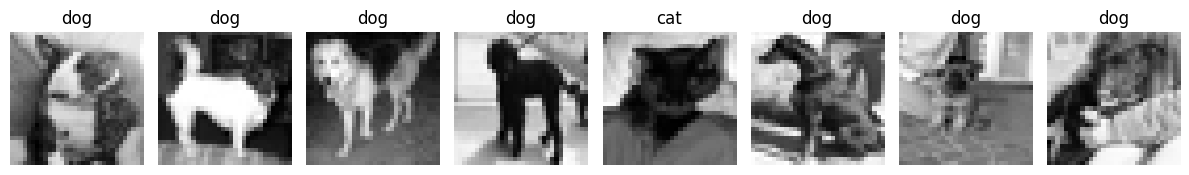

In [21]:
# Визуализируем несколько картинок

def show_examples(X, y, n=8):
    idx = np.random.choice(len(X), size=n, replace=False)
    plt.figure(figsize=(12, 3))
    for i, j in enumerate(idx):
        plt.subplot(1, n, i + 1)
        plt.imshow(X[j].reshape(32, 32), cmap="gray")
        plt.axis("off")
        plt.title("dog" if y[j] == 1 else "cat")
    plt.tight_layout()
    plt.show()

show_examples(X_train_raw, y_train, n=8)


In [22]:
# Реализация логистической регрессии (binary) на numpy

class LogisticRegressionBinary:
    def __init__(self, lr=0.1, n_epochs=200, batch_size=64, verbose=True):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.W = None
        self.b = None

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.W = np.zeros(n_features, dtype=np.float32)
        self.b = 0.0

        for epoch in range(self.n_epochs):
            # стохастический градиентный спуск с мини-батчами
            indices = np.random.permutation(n_samples)
            X_shuffled, y_shuffled = X[indices], y[indices]

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                xb = X_shuffled[start:end]
                yb = y_shuffled[start:end]

                logits = xb @ self.W + self.b
                probs = self._sigmoid(logits)

                # градиенты
                grad_logits = probs - yb
                grad_W = xb.T @ grad_logits / len(xb)
                grad_b = grad_logits.mean()

                # шаг
                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b

            if self.verbose and (epoch + 1) % 20 == 0:
                train_loss = self._log_loss(X, y)
                if X_val is not None:
                    val_loss = self._log_loss(X_val, y_val)
                    print(f"Epoch {epoch+1:4d}: train loss={train_loss:.4f}, val loss={val_loss:.4f}")
                else:
                    print(f"Epoch {epoch+1:4d}: train loss={train_loss:.4f}")

    def _log_loss(self, X, y):
        logits = X @ self.W + self.b
        probs = self._sigmoid(logits)
        eps = 1e-8
        return -np.mean(y * np.log(probs + eps) + (1 - y) * np.log(1 - probs + eps))

    def predict_proba(self, X):
        logits = X @ self.W + self.b
        probs = self._sigmoid(logits)
        return np.vstack([1 - probs, probs]).T  # [p0, p1]

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)


In [33]:
# Делим train ещё на train/val для подбора гиперпараметров

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model_catdog = LogisticRegressionBinary(lr=0.1, n_epochs=200, batch_size=64, verbose=True)
model_catdog.fit(X_tr, y_tr, X_val, y_val)


# Оценка на train/val/test

for split_name, X_split, y_split in [
    ("train", X_tr, y_tr),
    ("val",   X_val, y_val),
    ("test",  X_test_raw, y_test),
]:
    y_pred = model_catdog.predict(X_split)
    acc = accuracy_score(y_split, y_pred)
    print(f"{split_name:5s}: accuracy = {acc:.3f}")


Epoch   20: train loss=2.8304, val loss=2.7598
Epoch   40: train loss=1.3985, val loss=1.5103
Epoch   60: train loss=1.8593, val loss=1.9497
Epoch   80: train loss=2.4761, val loss=2.5551
Epoch  100: train loss=0.7806, val loss=1.0447
Epoch  120: train loss=1.7369, val loss=1.9888
Epoch  140: train loss=1.1776, val loss=1.6346
Epoch  160: train loss=0.5516, val loss=0.9974
Epoch  180: train loss=2.4267, val loss=2.7353
Epoch  200: train loss=1.2482, val loss=1.6788
train: accuracy = 0.585
val  : accuracy = 0.520
test : accuracy = 0.522


Ошибок на тесте: 191


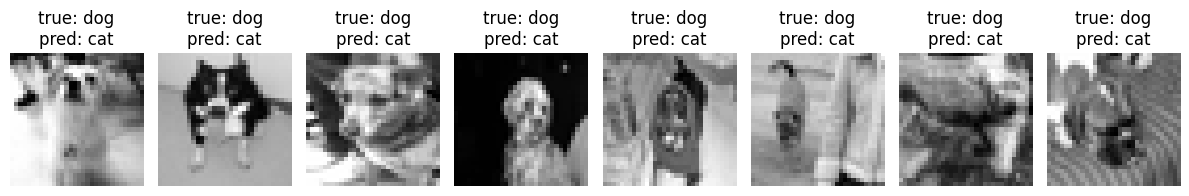

In [34]:
# Посмотрим примеры ошибок модели

y_pred_test = model_catdog.predict(X_test_raw)
wrong_idx = np.where(y_pred_test != y_test)[0]
print("Ошибок на тесте:", len(wrong_idx))

n_show = min(8, len(wrong_idx))
if n_show > 0:
    idx = np.random.choice(wrong_idx, size=n_show, replace=False)
    plt.figure(figsize=(12, 3))
    for i, j in enumerate(idx):
        plt.subplot(1, n_show, i + 1)
        plt.imshow(X_test_raw[j].reshape(32, 32), cmap="gray")
        plt.axis("off")
        plt.title(f"true: {'dog' if y_test[j] == 1 else 'cat'}\n"
                  f"pred: {'dog' if y_pred_test[j] == 1 else 'cat'}")
    plt.tight_layout()
    plt.show()
